# boamotion — building blocks

The pieces the analysis is assembled from: the parameter object, the synthetic test
recording, and the frame reader. Run **Imports** first, then any section on its own.

For what the analysis actually computes and what each parameter changes, see
[`HOW_IT_WORKS.md`](../HOW_IT_WORKS.md).

## Imports

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from boamotion import (
    Params,
    detect_reference_frame,
    load_frames,
    pixel_mask,
    synthetic_recording,
)

work_dir = Path(tempfile.mkdtemp(prefix="boamotion-"))
work_dir

WindowsPath('C:/Users/roman/AppData/Local/Temp/boamotion-fk_508mf')

## 1. Parameters

`Params` holds every setting of an analysis. It can be built from keyword arguments,
changed afterwards attribute by attribute, or read from a file.

### 1.1 Defaults

Constructed empty, it carries the defaults of the original MUSCLEMOTION macro.

In [2]:
Params()

Params(framerate=100.0, speed_window=2, reference_frame=None, ref_search_start=1, ref_search_stop=300, n_low_values=20, n_unity_values=10, noise_reduction=True, mask_start_frame=1, mask_end_frame=None, transient_analysis=True, peak_window=20, peak_threshold=30.0, percentages=(10, 50, 90), baseline_threshold=2.0, baseline_n_points=5, high_freq_baseline=True, legacy=True)

In [3]:
defaults = Params()
print("frame rate       :", defaults.framerate, "fps")
print("time per frame   :", defaults.sampling_interval_ms, "ms")
print("reference frame  :", defaults.reference_frame, "(None means detect it automatically)")

frame rate       : 100.0 fps
time per frame   : 10.0 ms
reference frame  : None (None means detect it automatically)


### 1.2 Setting parameters

Keyword arguments for the values you know up front, attributes for anything you change
later. Both are checked.

In [4]:
params = Params(framerate=25, peak_threshold=50, high_freq_baseline=False)
params.peak_window = 20
params

Params(framerate=25, speed_window=2, reference_frame=None, ref_search_start=1, ref_search_stop=300, n_low_values=20, n_unity_values=10, noise_reduction=True, mask_start_frame=1, mask_end_frame=None, transient_analysis=True, peak_window=20, peak_threshold=50, percentages=(10, 50, 90), baseline_threshold=2.0, baseline_n_points=5, high_freq_baseline=False, legacy=True)

### 1.3 Saving and loading

Writing the parameters next to a result is what makes that result reproducible later. The
file is plain YAML, so it can also be written by hand or generated for a batch of jobs.

In [5]:
params_file = params.to_yaml(work_dir / "params.yaml")
print(params_file.read_text())

framerate: 25
speed_window: 2
reference_frame: null
ref_search_start: 1
ref_search_stop: 300
n_low_values: 20
n_unity_values: 10
noise_reduction: true
mask_start_frame: 1
mask_end_frame: null
transient_analysis: true
peak_window: 20
peak_threshold: 50
percentages:
- 10
- 50
- 90
baseline_threshold: 2.0
baseline_n_points: 5
high_freq_baseline: false
legacy: true



In [6]:
Params.from_yaml(params_file) == params

True

### 1.4 Validation

Impossible settings are refused immediately rather than producing puzzling results much
later, and a mistyped name in a file is an error rather than a silently ignored line.

In [7]:
try:
    Params(framerate=0)
except ValueError as error:
    print(error)

framerate must be positive, got 0


In [8]:
typo_file = work_dir / "typo.yaml"
typo_file.write_text("frame_rate: 25\n", encoding="utf-8")

try:
    Params.from_yaml(typo_file)
except ValueError as error:
    print(error)

unknown parameter(s): frame_rate. Valid names are: baseline_n_points, baseline_threshold, framerate, high_freq_baseline, legacy, mask_end_frame, mask_start_frame, n_low_values, n_unity_values, noise_reduction, peak_threshold, peak_window, percentages, ref_search_start, ref_search_stop, reference_frame, speed_window, transient_analysis


## 2. A synthetic recording

`synthetic_recording()` generates a beating movie whose peak frames, rest frames and beat
period are known exactly. It lets the analysis be tested against answers we chose
ourselves, and stands in for a real recording while developing.

### 2.1 Generating one

`noise` adds Gaussian camera noise as a fraction of full brightness and `seed` makes it
reproducible. Use `noise=0` for a perfectly clean recording.

In [9]:
recording = synthetic_recording(noise=0.01, seed=0)
recording

SyntheticRecording(100 frames, 80 x 64, 4 beats at 25.0 fps)

In [10]:
print("frames          :", recording.n_frames)
print("frames per beat :", recording.frames_per_beat)
print("beat interval   :", recording.beat_interval_ms, "ms")
print("peaks at frames :", recording.peak_frames)
print("first rest frame:", recording.rest_frames[0])

frames          : 100
frames per beat : 25
beat interval   : 1000.0 ms
peaks at frames : (16, 41, 66, 91)
first rest frame: 1


### 2.2 Looking at the frames

A bright blob shifts sideways once per beat, next to a second blob that never moves. Frame
numbers are 1-based throughout the package, hence the `- 1` when indexing the array.

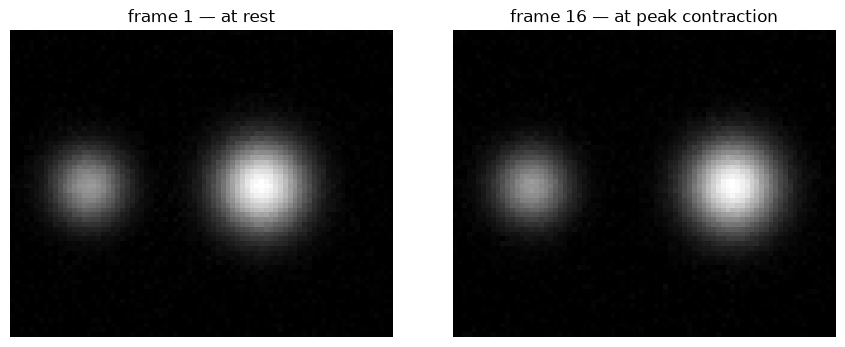

In [11]:
rest_frame = recording.rest_frames[0]
peak_frame = recording.peak_frames[0]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].imshow(recording.frames[rest_frame - 1], cmap="gray")
axes[0].set_title(f"frame {rest_frame} — at rest")
axes[1].imshow(recording.frames[peak_frame - 1], cmap="gray")
axes[1].set_title(f"frame {peak_frame} — at peak contraction")
axes[0].axis("off")
axes[1].axis("off")
fig.tight_layout()

### 2.3 The difference image

This is the entire idea behind the measurement. Subtract the resting frame from a frame of
interest and take the absolute value: the stationary blob disappears, and only what moved
lights up. Averaging this image over all pixels gives **one point** of the contraction
trace.

mean over all pixels: 2145.9614


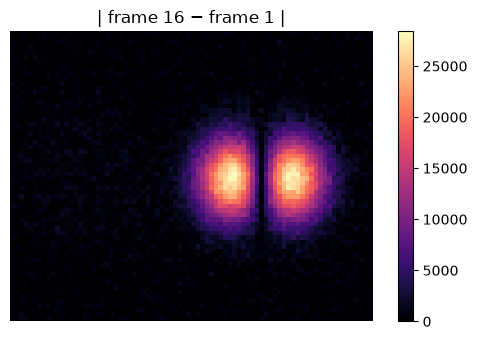

In [12]:
rest = recording.frames[rest_frame - 1].astype(np.float32)
peak = recording.frames[peak_frame - 1].astype(np.float32)
difference = np.abs(peak - rest)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
shown = ax.imshow(difference, cmap="magma")
ax.set_title(f"| frame {peak_frame} − frame {rest_frame} |")
ax.axis("off")
fig.colorbar(shown, ax=ax)
fig.tight_layout()

print("mean over all pixels:", difference.mean())

## 3. Reading a recording from disk

Real recordings arrive as one TIFF file per frame. `load_frames()` opens such a directory
and reads frames on demand, so memory use does not grow with the length of the recording.

### 3.1 Writing the synthetic recording out

In [13]:
movie_dir = recording.write(work_dir / "synthetic_movie")
sorted(path.name for path in movie_dir.iterdir())[:4]

['frame_0001.tif', 'frame_0002.tif', 'frame_0003.tif', 'frame_0004.tif']

### 3.2 Opening it

In [14]:
frames = load_frames(movie_dir)
frames

FrameSequence('synthetic_movie', 100 frames, 80 x 64, uint16)

In [15]:
print("frames :", frames.n_frames)
print("size   :", frames.shape, "(height, width)")
print("dtype  :", frames.dtype)

frames : 100
size   : (64, 80) (height, width)
dtype  : uint16


### 3.3 Reading individual frames

Indexing reads one file, iteration walks the recording in order. Only the first frame is
read when the recording is opened, so nothing is loaded until it is asked for.

In [16]:
first = frames[0]
last = frames[-1]
print("first frame:", first.shape, first.dtype)
print("same data as the generated array:", np.array_equal(first, recording.frames[0]))

first frame: (64, 80) uint16
same data as the generated array: True


## 4. Finding the reference frame

Every measurement is made against a frame in which the tissue is at rest.
`detect_reference_frame` finds one by looking for moments that are quiet *and staying
quiet*, which is what separates true rest from the momentary standstill at the top of a
beat. [`HOW_IT_WORKS.md`](../HOW_IT_WORKS.md) explains the method.

`legacy=False` runs it as documented. `legacy=True` instead reproduces the original
MUSCLEMOTION macro, including two off-by-one errors that change which frame is chosen —
useful for comparing against existing FIJI results, and worth trying here to see how far
apart the two answers fall.

In [17]:
reference_frame = detect_reference_frame(frames, legacy=False)

print("detected reference frame :", reference_frame)
print("one of the resting frames:", reference_frame in recording.rest_frames)

ref_search_stop reduced from 300 to 97: the recording has 100 frames


detected reference frame : 52
one of the resting frames: True


The warning above is the analysis reporting what it did: the default search range covers
the first 300 frames, and this recording only has 100, so the range was shrunk to fit.

## 5. Preview: what this adds up to

The three lines below are the core measurement written out by hand — not the package's
implementation, which arrives in later steps together with the pixel mask and the peak
analysis. It is here to show that the pieces above already reach a contraction trace.

Dashed lines mark the peak frames the recording was built with.

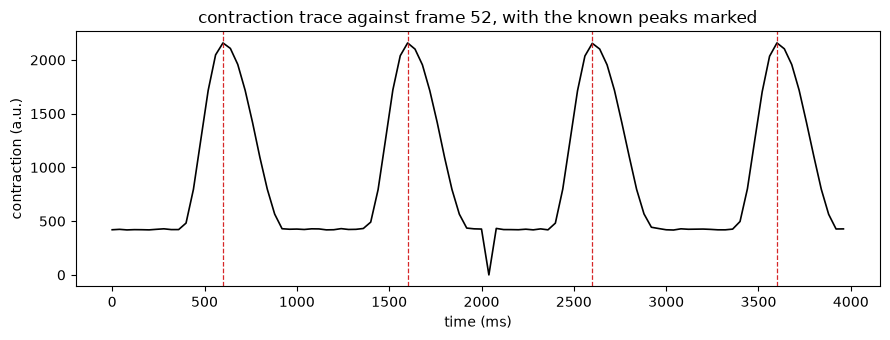

In [18]:
reference = frames[reference_frame - 1].astype(np.float32)
trace = np.array([np.abs(frame.astype(np.float32) - reference).mean() for frame in frames])
time_ms = np.arange(len(trace)) * (1000.0 / recording.framerate)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(time_ms, trace, color="black", linewidth=1.2)
for frame_number in recording.peak_frames:
    ax.axvline(
        (frame_number - 1) * 1000.0 / recording.framerate,
        color="tab:red",
        linestyle="--",
        linewidth=0.9,
    )
ax.set_xlabel("time (ms)")
ax.set_ylabel("contraction (a.u.)")
ax.set_title(f"contraction trace against frame {reference_frame}, with the known peaks marked")
fig.tight_layout()

Four humps, one per beat, each centred on a dashed line.

**The trace does not return to zero between beats** — it settles around 400-500. That is
the noise floor, and it is expected: this recording has `noise=0.01`, so every frame
carries its own noise and two resting frames still differ. Because the measurement takes
the *absolute* difference those differences cannot cancel, so they average to a positive
number, here about 20% of the peak. With `noise=0` the trace reaches exactly zero at rest.
The single point that is exactly zero is the reference frame compared against itself.

This is what the pixel mask exists for. Three quarters of this frame is dark background
that never moves but still feeds noise into every average, lifting the baseline and
shrinking the contraction relative to it. Restricting the mean to pixels that actually
move removes most of that floor, which is what the next section does.

## 6. Restricting the measurement to pixels that move

`pixel_mask` removes the floor seen above. It accumulates the largest change each pixel
ever shows against the reference frame, then keeps whatever exceeds the mean plus one
standard deviation of that map.

In [19]:
mask = pixel_mask(frames, reference_frame, legacy=False)

print("pixels kept:", mask.sum(), f"of {mask.size} ({100 * mask.mean():.1f}%)")

pixels kept: 493 of 5120 (9.6%)


### 6.1 What the mask selects

The moving blob is kept and the stationary one is discarded, even though both are bright.
Brightness is irrelevant here — only *change* matters.

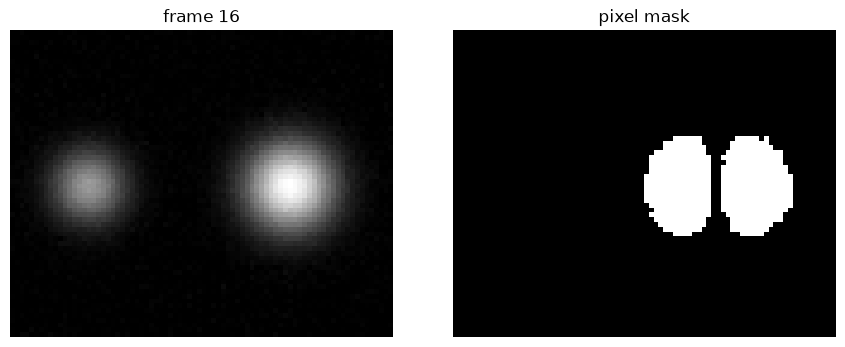

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].imshow(recording.frames[peak_frame - 1], cmap="gray")
axes[0].set_title(f"frame {peak_frame}")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("pixel mask")
axes[0].axis("off")
axes[1].axis("off")
fig.tight_layout()

### 6.2 The effect on the noise floor

Averaging over only the moving pixels leaves the resting level far closer to zero,
relative to the peak.

whole frame  resting level is 19.1% of the peak
masked       resting level is  3.7% of the peak


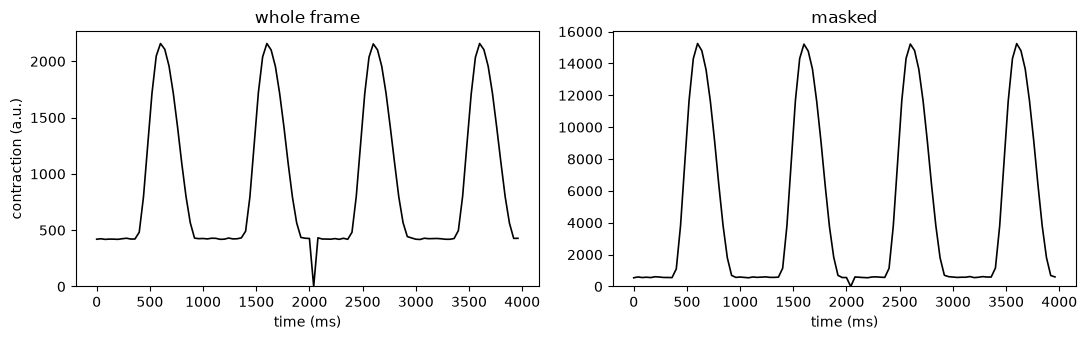

In [21]:
def contraction(pixels=None):
    """Mean change from the reference frame, over the whole frame or just `pixels`."""
    values = []
    for frame in frames:
        change = np.abs(frame.astype(np.float32) - reference)
        values.append(change[pixels].mean() if pixels is not None else change.mean())
    return np.array(values)


whole_frame = contraction()
masked = contraction(mask)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, values, title in ((axes[0], whole_frame, "whole frame"), (axes[1], masked, "masked")):
    ax.plot(time_ms, values, color="black", linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel("time (ms)")
    ax.set_ylim(0, values.max() * 1.05)
axes[0].set_ylabel("contraction (a.u.)")
fig.tight_layout()

for name, values in (("whole frame", whole_frame), ("masked", masked)):
    rest = values[np.array(recording.rest_frames) - 1].mean()
    peak = values[np.array(recording.peak_frames) - 1].mean()
    print(f"{name:12s} resting level is {100 * rest / peak:4.1f}% of the peak")

The resting level drops from roughly a fifth of the peak to a few percent.

Note the two plots have different vertical scales. Masking changes the absolute numbers as
well as the ratio, so masked and unmasked amplitudes cannot be compared with each other —
only within one setting.